# 🏦 HDFC Loan Approval Prediction

In [2]:
# Installing required libraries
%pip install -q kaggle scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [4]:
loan_data_file = 'Loan_Dataset.csv'
df = pd.read_csv(loan_data_file) 
print(df.head())

   Applicant_ID  Gender  Age Marital_Status  Dependents     Education  \
0             1  Female   25        Married           2      Graduate   
1             2    Male   36        Married           2   High School   
2             3    Male   43         Single           0  Postgraduate   
3             4  Female   28        Married           0   High School   
4             5  Female   32         Single           0      Graduate   

  Employment_Status Occupation_Type Residential_Status City/Town  ...  \
0          Employed        Business                Own     Urban  ...   
1          Employed        Business                Own  Suburban  ...   
2     Self-Employed      Freelancer                Own     Urban  ...   
3     Self-Employed      Freelancer               Rent  Suburban  ...   
4          Employed        Salaried               Rent  Suburban  ...   

   Loan_Amount_Requested  Loan_Term  Loan_Purpose  Interest_Rate  Loan_Type  \
0                  24535        209        

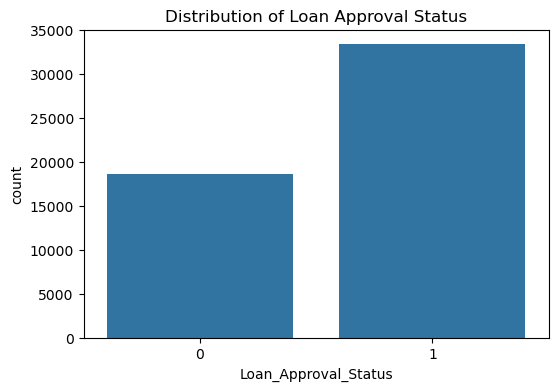

In [5]:
# Dataset Loan approval distribution visualization
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Approval_Status', data=df)
plt.title('Distribution of Loan Approval Status')
plt.show()

### Data Pre-processing

In [6]:
df.drop('Applicant_ID', axis=1, inplace=True)

# Fill missing categorical values with the mode
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical columns with the median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# Calculate the Debt-to-Income (DTI) Ratio
# DTI is a crucial metric used by real banks to assess risk
df['Monthly_Income'] = df['Annual_Income'] / 12
df['DTI_Ratio'] = df['Monthly_Expenses'] / df['Monthly_Income']
df = df.drop('Monthly_Income', axis=1)

# ---------------------------------------------------------
# Step 3: Encoding Categorical Variables
# ---------------------------------------------------------
# 3a. Label Encoding for binary categories (2 options)
binary_cols = ['Gender', 'Marital_Status', 'Education', 'Loan_Type', 'Co-Applicant']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# 3b. One-Hot Encoding for nominal categories (3+ options)
# drop_first=True prevents the "dummy variable trap" (multicollinearity)
nominal_cols = ['Employment_Status', 'Occupation_Type', 'Residential_Status', 'City/Town', 'Loan_Purpose']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Pre-processing complete. Current shape:", df.shape)

Pre-processing complete. Current shape: (52000, 34)


In [7]:
# ---------------------------------------------------------
# Step 4: Model Development & Implementation (12 Marks)
# ---------------------------------------------------------
# Separate features (X) and target variable (y)
X = df.drop('Loan_Approval_Status', axis=1)
y = df['Loan_Approval_Status']

# Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling: Standardize the data so large values (Income) 
# don't overpower small values (Interest Rate)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
log_pred = log_reg.predict(X_test_scaled)

# Model 2: Decision Tree Classifier
dtree_model = DecisionTreeClassifier(random_state=42)
dtree_model.fit(X_train_scaled, y_train)
dtree_pred = dtree_model.predict(X_test_scaled)

# Model 3: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

In [8]:
print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, log_pred):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, log_pred))
print("Classification Report:\n", classification_report(y_test, log_pred, zero_division=0))

print("\n--- Decision Tree Performance ---")
print(f"Accuracy: {accuracy_score(y_test, dtree_pred):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, dtree_pred))
print("Classification Report:\n", classification_report(y_test, dtree_pred, zero_division=0))

print("\n--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred, zero_division=0))

--- Logistic Regression Performance ---
Accuracy: 0.86
Confusion Matrix:
 [[2541 1062]
 [ 444 6353]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.71      0.77      3603
           1       0.86      0.93      0.89      6797

    accuracy                           0.86     10400
   macro avg       0.85      0.82      0.83     10400
weighted avg       0.85      0.86      0.85     10400


--- Decision Tree Performance ---
Accuracy: 0.73
Confusion Matrix:
 [[2310 1293]
 [1468 5329]]
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.64      0.63      3603
           1       0.80      0.78      0.79      6797

    accuracy                           0.73     10400
   macro avg       0.71      0.71      0.71     10400
weighted avg       0.74      0.73      0.74     10400


--- Random Forest Performance ---
Accuracy: 0.86
Confusion Matrix:
 [[2549 1054]
 [ 446 6351]]
Class

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Define the exact metrics you want the cross-validation to track
# This hits the "Performance Evaluation" rubric perfectly!
scoring_metrics = ['accuracy', 'f1', 'precision', 'recall']

print("Running 5-Fold Cross-Validation on Training Data...\n")

# 4. Loop through each model, run the practice tests, and print the report card
for name, model in models.items():
    print(f"==================================================")
    print(f"--- {name} ---")
    
    # The pipeline ensures scaling happens strictly within the training folds
    pipeline = make_pipeline(StandardScaler(), model)
    
    # Run the cross-validation on the TRAINING data
    cv_results = cross_validate(pipeline, X_train, y_train, cv=skf, scoring=scoring_metrics)
    
    # Extract the average scores across all 5 folds
    mean_acc = np.mean(cv_results['test_accuracy'])
    mean_f1 = np.mean(cv_results['test_f1'])
    mean_precision = np.mean(cv_results['test_precision'])
    mean_recall = np.mean(cv_results['test_recall'])
    
    print(f"Accuracy:  {mean_acc:.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")
    print(f"F1-Score:  {mean_f1:.4f} (+/- {np.std(cv_results['test_f1']):.4f})")
    print(f"Precision: {mean_precision:.4f}")
    print(f"Recall:    {mean_recall:.4f}\n")

print(f"==================================================")

Running 5-Fold Cross-Validation on Training Data...

--- Logistic Regression ---
Accuracy:  0.8477 (+/- 0.0024)
F1-Score:  0.8864 (+/- 0.0014)
Precision: 0.8468
Recall:    0.9298

--- Decision Tree ---
Accuracy:  0.8399 (+/- 0.0044)
F1-Score:  0.8803 (+/- 0.0029)
Precision: 0.8425
Recall:    0.9216

--- Random Forest ---
Accuracy:  0.8485 (+/- 0.0022)
F1-Score:  0.8869 (+/- 0.0013)
Precision: 0.8479
Recall:    0.9296



C:\Users\tsaty\AppData\Local\Temp\ipykernel_31224\103716.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=dt_importance_df.head(10), palette='magma')


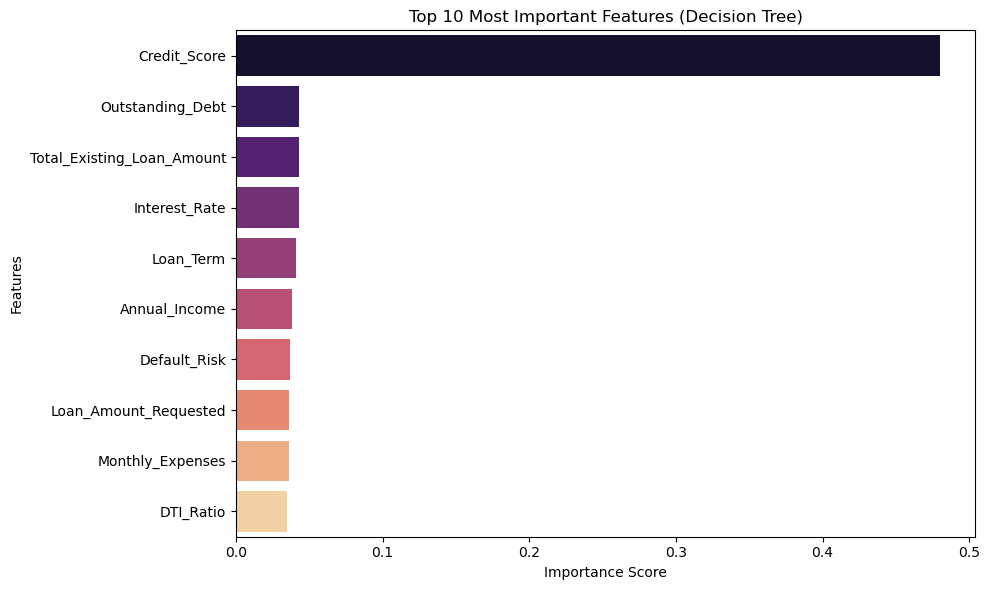

In [10]:
# 2. Extract the importances directly from the tree
dt_importances = dtree_model.feature_importances_

# 3. Create a DataFrame and sort them
dt_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_importances
}).sort_values(by='Importance', ascending=False)



# 4. Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=dt_importance_df.head(10), palette='magma')
plt.title('Top 10 Most Important Features (Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

C:\Users\tsaty\AppData\Local\Temp\ipykernel_31224\3459038462.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


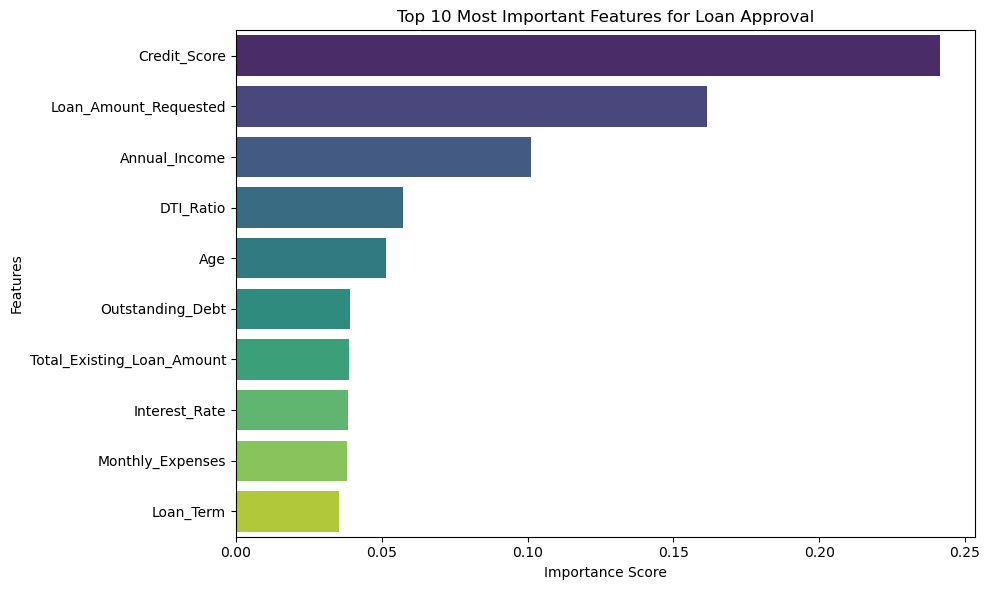

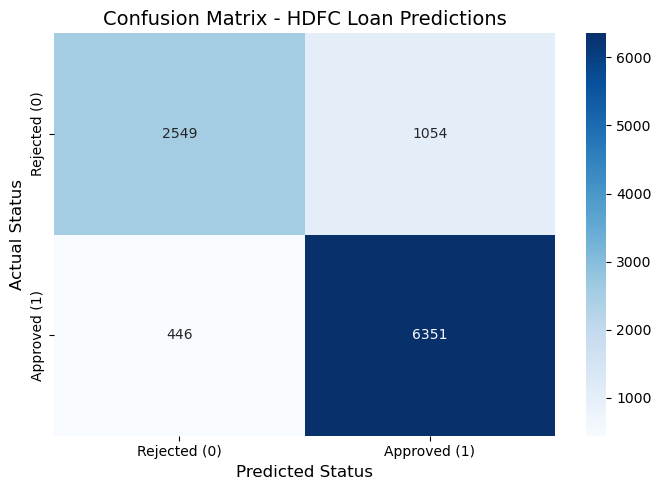

In [11]:
importances = rf_model.feature_importances_

# 2. Get the names of the columns you trained the model on
feature_names = X_train.columns

# 3. Create a DataFrame to hold them, then sort from highest to lowest
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features for Loan Approval')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 1. Generate the raw confusion matrix numbers
cm = confusion_matrix(y_test, rf_pred)

# 2. Plot it using Seaborn's heatmap
plt.figure(figsize=(7, 5))
# annot=True puts the numbers in the boxes, fmt='g' prevents scientific notation
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'])

# 3. Add labels and title for clarity
plt.title('Confusion Matrix - HDFC Loan Predictions', fontsize=14)
plt.xlabel('Predicted Status', fontsize=12)
plt.ylabel('Actual Status', fontsize=12)
plt.tight_layout()
plt.show()